<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/Task09_Model_Evaluation_%26_Metrics_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, classification_report, roc_curve,
                             roc_auc_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Display first few rows
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Check class distribution
print("\nSurvival Distribution:")
print(df['Survived'].value_counts())
print(f"\nPercentage of survivors: {df['Survived'].mean()*100:.2f}%")
print(f"Percentage of non-survivors: {(1-df['Survived'].mean())*100:.2f}%")

Dataset shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

Missing values before preprocessing:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after preprocessing:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
dtype: int64

Processed data shape: (891, 10)


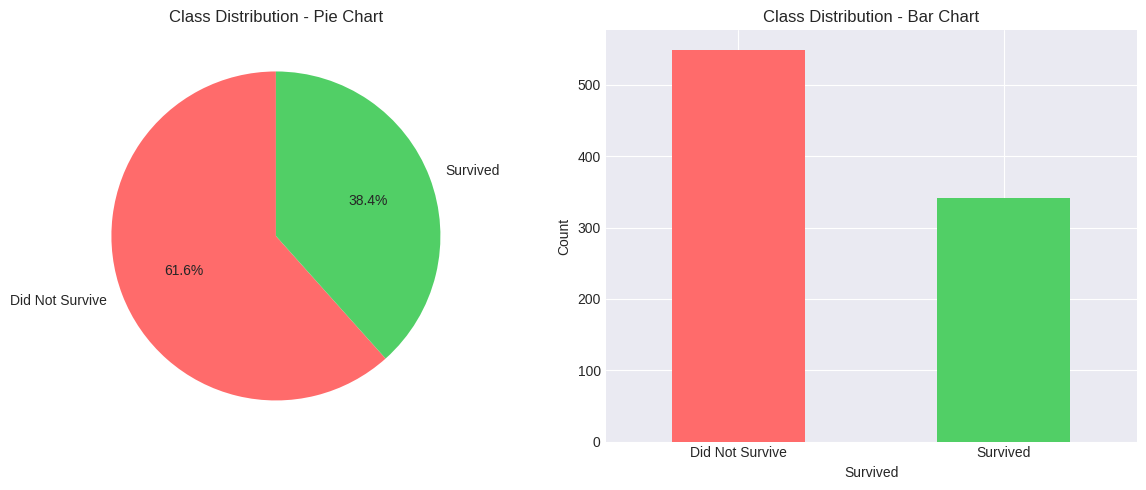


Training set size: 712
Test set size: 179

Training set survival rate: 38.34%
Test set survival rate: 38.55%


In [2]:
# Check for missing values
print("Missing values before preprocessing:")
print(df.isnull().sum())

# Data preprocessing function
def preprocess_titanic(df):
    # Make a copy
    data = df.copy()

    # Drop unnecessary columns
    data = data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

    # Fill missing values
    data['Age'] = data['Age'].fillna(data['Age'].median())
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
    data['Fare'] = data['Fare'].fillna(data['Fare'].median())

    # Convert categorical variables
    data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
    data['Embarked'] = data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    # Create family size feature
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

    return data

# Preprocess the data
df_processed = preprocess_titanic(df)

print("\nMissing values after preprocessing:")
print(df_processed.isnull().sum())
print("\nProcessed data shape:", df_processed.shape)

# Visualize the class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(df_processed['Survived'].value_counts(),
            labels=['Did Not Survive', 'Survived'],
            autopct='%1.1f%%',
            colors=['#ff6b6b', '#51cf66'],
            startangle=90)
axes[0].set_title('Class Distribution - Pie Chart')

# Bar chart
df_processed['Survived'].value_counts().plot(kind='bar', ax=axes[1],
                                              color=['#ff6b6b', '#51cf66'])
axes[1].set_title('Class Distribution - Bar Chart')
axes[1].set_xlabel('Survived')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Did Not Survive', 'Survived'], rotation=0)

plt.tight_layout()
plt.show()

# Prepare features and target
X = df_processed.drop('Survived', axis=1)
y = df_processed['Survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set survival rate: {y_train.mean()*100:.2f}%")
print(f"Test set survival rate: {y_test.mean()*100:.2f}%")

DUMMY CLASSIFIER (Always predicts 'Not Survived')
Accuracy: 61.45%
Precision: 0.00
Recall: 0.00
F1-Score: 0.00


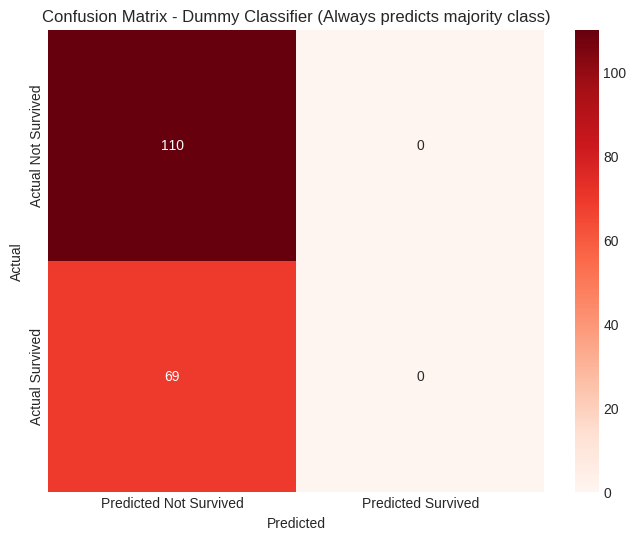


🔍 KEY INSIGHT: The dummy classifier achieves high accuracy
but completely fails to identify any survivors!
This is why we need precision, recall, and F1-score.


In [3]:
# Create a "dummy" classifier that always predicts the majority class (not survived)
from sklearn.dummy import DummyClassifier

# Create dummy classifier
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

# Calculate accuracy
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
print("="*50)
print("DUMMY CLASSIFIER (Always predicts 'Not Survived')")
print("="*50)
print(f"Accuracy: {dummy_accuracy:.2%}")
print(f"Precision: {precision_score(y_test, y_pred_dummy, zero_division=0):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_dummy, zero_division=0):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dummy, zero_division=0):.2f}")

# Visualize the confusion matrix
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Not Survived', 'Predicted Survived'],
            yticklabels=['Actual Not Survived', 'Actual Survived'])
plt.title('Confusion Matrix - Dummy Classifier (Always predicts majority class)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n🔍 KEY INSIGHT: The dummy classifier achieves high accuracy")
print("but completely fails to identify any survivors!")
print("This is why we need precision, recall, and F1-score.")

LOGISTIC REGRESSION MODEL PERFORMANCE
Accuracy: 80.45%
Precision: 0.78
Recall: 0.68
F1-Score: 0.73


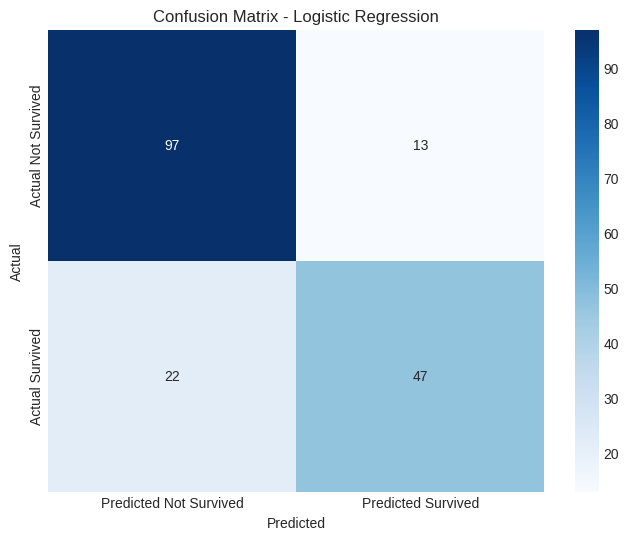


📊 Confusion Matrix Breakdown:
True Negatives (correctly predicted not survived): 97
False Positives (incorrectly predicted survived): 13
False Negatives (incorrectly predicted not survived): 22
True Positives (correctly predicted survived): 47


In [4]:
# Train a Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]  # Probability of survival

# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Not Survived', 'Predicted Survived'],
            yticklabels=['Actual Not Survived', 'Actual Survived'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Interpretation
tn, fp, fn, tp = cm.ravel()
print("\n📊 Confusion Matrix Breakdown:")
print(f"True Negatives (correctly predicted not survived): {tn}")
print(f"False Positives (incorrectly predicted survived): {fp}")
print(f"False Negatives (incorrectly predicted not survived): {fn}")
print(f"True Positives (correctly predicted survived): {tp}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Not Survived       0.82      0.88      0.85       110
    Survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



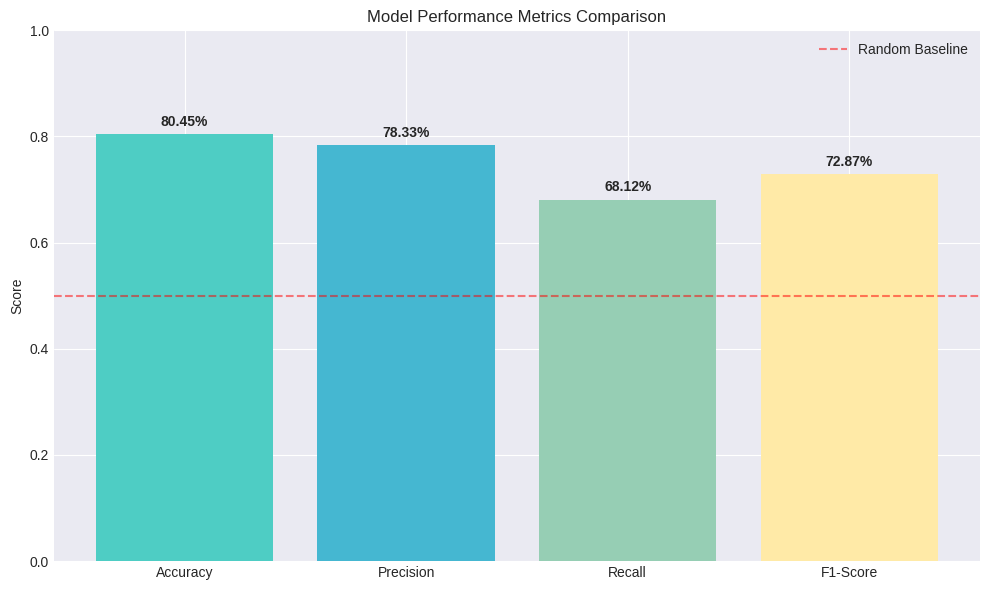

In [5]:
# Generate classification report
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred,
                           target_names=['Not Survived', 'Survived']))

# Visualize metrics comparison
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_df['Metric'], metrics_df['Score'],
               color=['#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Metrics Comparison')

# Add value labels on bars
for bar, score in zip(bars, metrics_df['Score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.2%}', ha='center', va='bottom', fontweight='bold')

plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline')
plt.legend()
plt.tight_layout()
plt.show()

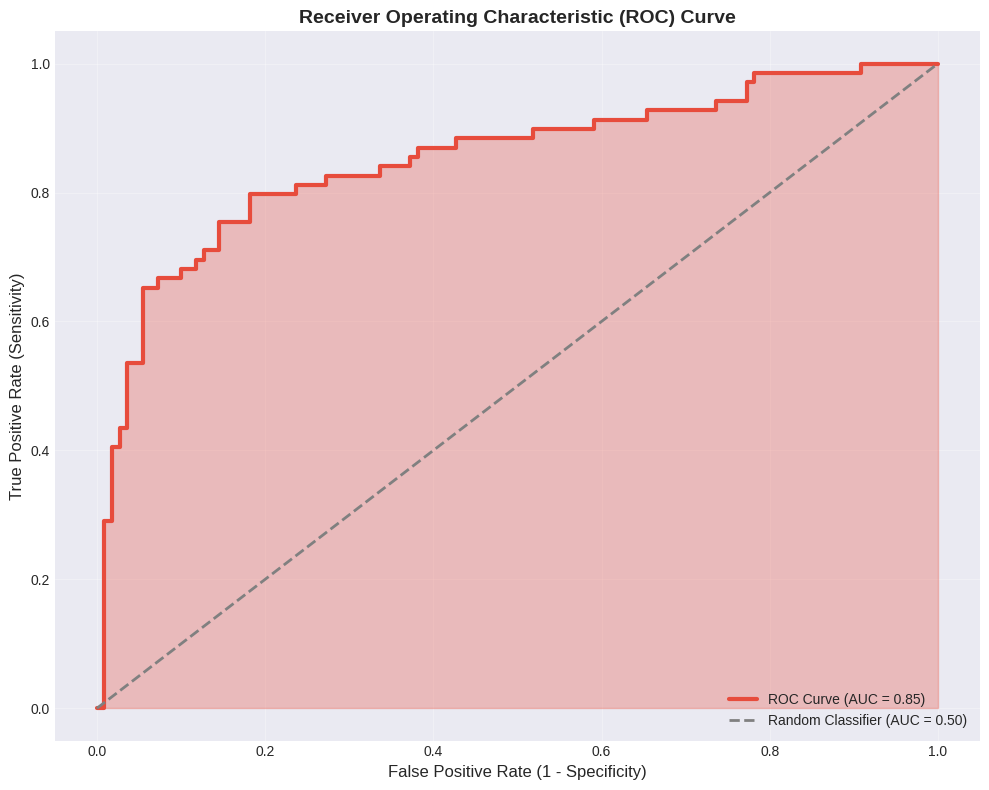

📈 AUC Score: 0.852

Interpretation:
Good discrimination - the model performs well


In [6]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=3, color='#e74c3c', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], '--', linewidth=2, color='gray', label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📈 AUC Score: {auc_score:.3f}")
print("\nInterpretation:")
if auc_score >= 0.9:
    print("Excellent discrimination - the model can distinguish well between classes")
elif auc_score >= 0.8:
    print("Good discrimination - the model performs well")
elif auc_score >= 0.7:
    print("Fair discrimination - the model has moderate performance")
elif auc_score > 0.5:
    print("Poor discrimination - slightly better than random")
else:
    print("Very poor discrimination - no better than random guessing")

PERFORMANCE AT DIFFERENT THRESHOLDS
   Threshold  Accuracy  Precision  Recall  F1-Score
0        0.3     0.771      0.667   0.812     0.732
1        0.4     0.799      0.732   0.754     0.743
2        0.5     0.804      0.783   0.681     0.729
3        0.6     0.821      0.878   0.623     0.729
4        0.7     0.782      0.895   0.493     0.636


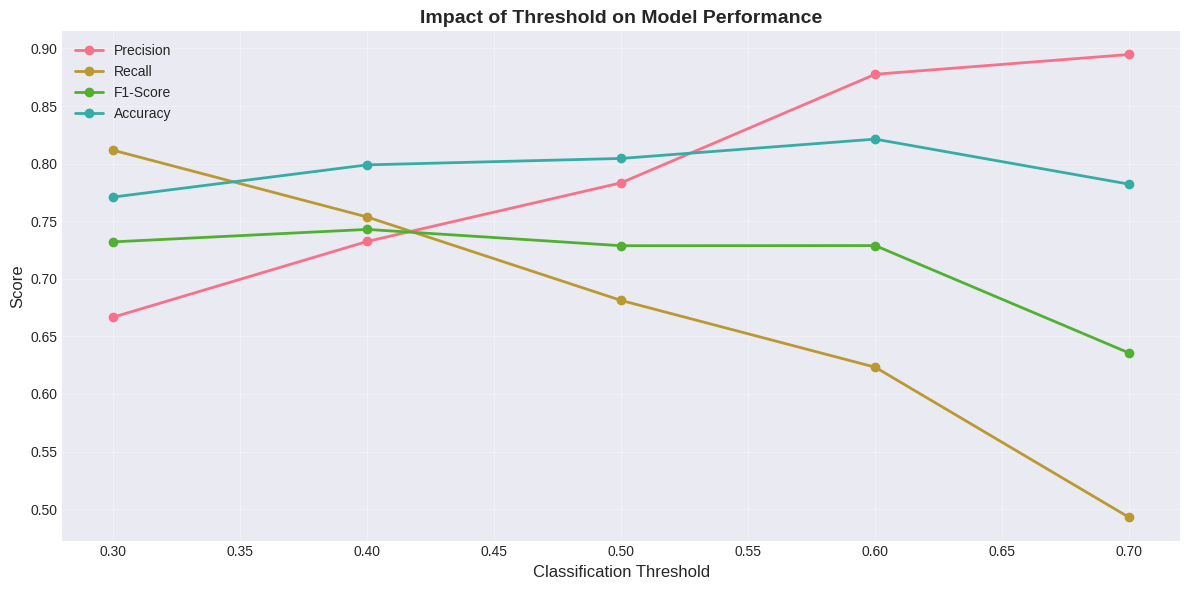

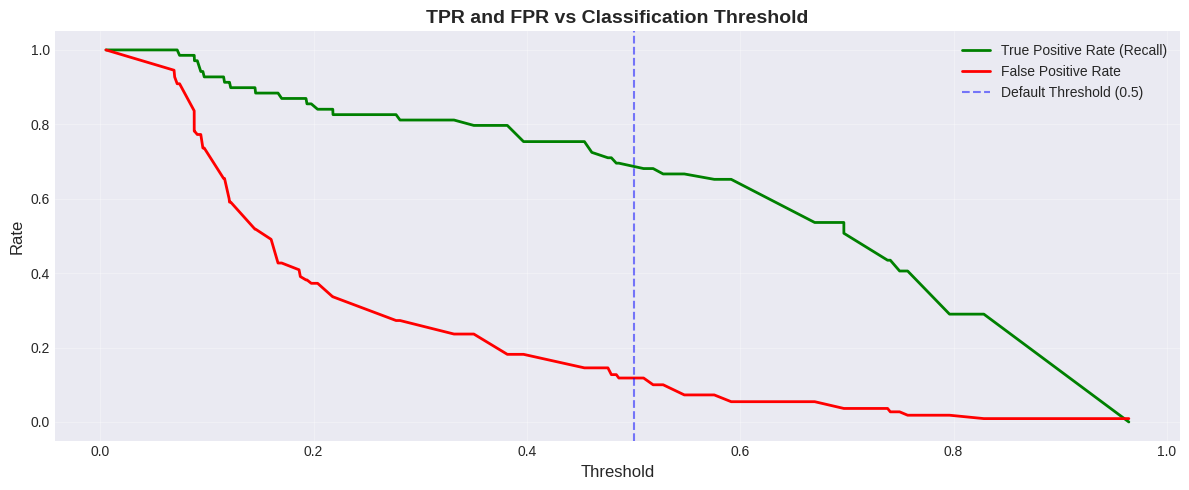

In [7]:
# Analyze different probability thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_probs >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_threshold)
    rec = recall_score(y_test, y_pred_threshold)
    f1_thresh = f1_score(y_test, y_pred_threshold)
    acc = accuracy_score(y_test, y_pred_threshold)

    results.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1_thresh
    })

results_df = pd.DataFrame(results)
print("="*60)
print("PERFORMANCE AT DIFFERENT THRESHOLDS")
print("="*60)
print(results_df.round(3))

# Visualize threshold impact
plt.figure(figsize=(12, 6))
for column in ['Precision', 'Recall', 'F1-Score', 'Accuracy']:
    plt.plot(results_df['Threshold'], results_df[column], marker='o', linewidth=2, label=column)

plt.xlabel('Classification Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Impact of Threshold on Model Performance', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize threshold vs TP/FP rates
plt.figure(figsize=(12, 5))
plt.plot(thresholds, tpr, label='True Positive Rate (Recall)', linewidth=2, color='green')
plt.plot(thresholds, fpr, label='False Positive Rate', linewidth=2, color='red')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Rate', fontsize=12)
plt.title('TPR and FPR vs Classification Threshold', fontsize=14, fontweight='bold')
plt.axvline(x=0.5, color='blue', linestyle='--', alpha=0.5, label='Default Threshold (0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

5-FOLD CROSS-VALIDATION RESULTS

Accuracy Scores per fold:
  Fold 1: 0.777
  Fold 2: 0.792
  Fold 3: 0.798
  Fold 4: 0.792
  Fold 5: 0.831
  Mean Accuracy: 0.798 (+/- 0.036)

Precision Scores per fold:
  Fold 1: 0.704
  Fold 2: 0.754
  Fold 3: 0.796
  Fold 4: 0.738
  Fold 5: 0.791
  Mean Precision: 0.757 (+/- 0.068)

Recall Scores per fold:
  Fold 1: 0.725
  Fold 2: 0.676
  Fold 3: 0.632
  Fold 4: 0.706
  Fold 5: 0.768
  Mean Recall: 0.701 (+/- 0.091)

F1-Scores per fold:
  Fold 1: 0.714
  Fold 2: 0.713
  Fold 3: 0.705
  Fold 4: 0.722
  Fold 5: 0.779
  Mean F1-Score: 0.727 (+/- 0.054)


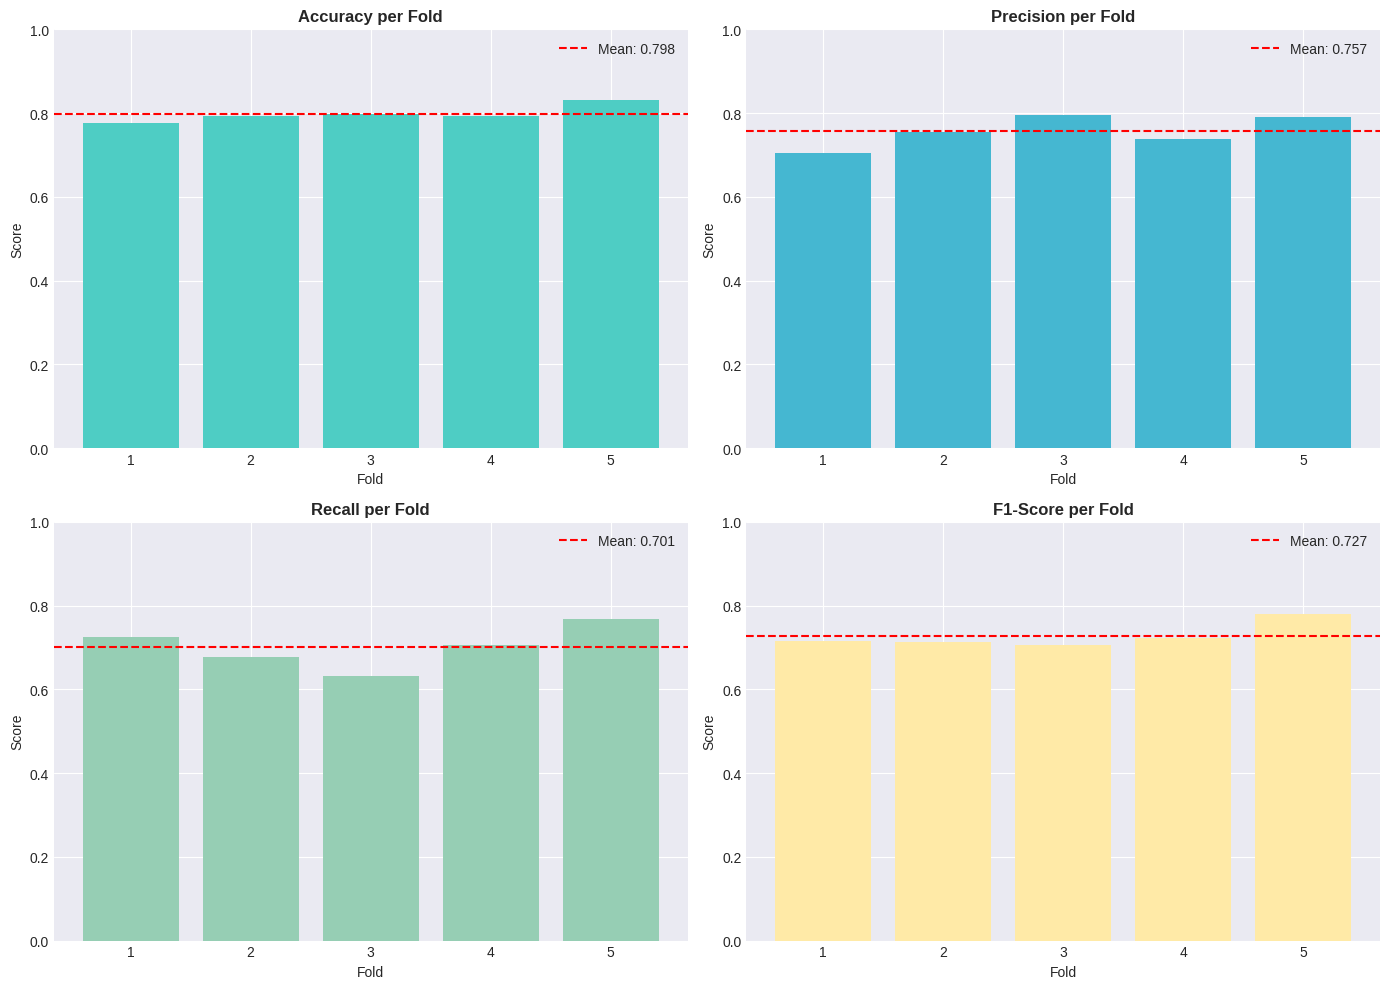


📊 COMPARISON: Single Train-Test Split vs Cross-Validation
-------------------------------------------------------
Single split accuracy: 0.804
Cross-validation accuracy: 0.798 (+/- 0.036)

Single split F1-score: 0.729
Cross-validation F1-score: 0.727 (+/- 0.054)


In [8]:
# Perform 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate cross-validation scores for different metrics
cv_accuracy = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(model, X, y, cv=cv, scoring='precision')
cv_recall = cross_val_score(model, X, y, cv=cv, scoring='recall')
cv_f1 = cross_val_score(model, X, y, cv=cv, scoring='f1')

print("="*60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*60)
print("\nAccuracy Scores per fold:")
for i, score in enumerate(cv_accuracy, 1):
    print(f"  Fold {i}: {score:.3f}")
print(f"  Mean Accuracy: {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std()*2:.3f})")

print("\nPrecision Scores per fold:")
for i, score in enumerate(cv_precision, 1):
    print(f"  Fold {i}: {score:.3f}")
print(f"  Mean Precision: {cv_precision.mean():.3f} (+/- {cv_precision.std()*2:.3f})")

print("\nRecall Scores per fold:")
for i, score in enumerate(cv_recall, 1):
    print(f"  Fold {i}: {score:.3f}")
print(f"  Mean Recall: {cv_recall.mean():.3f} (+/- {cv_recall.std()*2:.3f})")

print("\nF1-Scores per fold:")
for i, score in enumerate(cv_f1, 1):
    print(f"  Fold {i}: {score:.3f}")
print(f"  Mean F1-Score: {cv_f1.mean():.3f} (+/- {cv_f1.std()*2:.3f})")

# Visualize cross-validation results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].bar(range(1, 6), cv_accuracy, color='#4ecdc4')
axes[0, 0].axhline(y=cv_accuracy.mean(), color='red', linestyle='--',
                   label=f'Mean: {cv_accuracy.mean():.3f}')
axes[0, 0].set_title('Accuracy per Fold', fontweight='bold')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend()

# Precision
axes[0, 1].bar(range(1, 6), cv_precision, color='#45b7d1')
axes[0, 1].axhline(y=cv_precision.mean(), color='red', linestyle='--',
                   label=f'Mean: {cv_precision.mean():.3f}')
axes[0, 1].set_title('Precision per Fold', fontweight='bold')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()

# Recall
axes[1, 0].bar(range(1, 6), cv_recall, color='#96ceb4')
axes[1, 0].axhline(y=cv_recall.mean(), color='red', linestyle='--',
                   label=f'Mean: {cv_recall.mean():.3f}')
axes[1, 0].set_title('Recall per Fold', fontweight='bold')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

# F1-Score
axes[1, 1].bar(range(1, 6), cv_f1, color='#ffeaa7')
axes[1, 1].axhline(y=cv_f1.mean(), color='red', linestyle='--',
                   label=f'Mean: {cv_f1.mean():.3f}')
axes[1, 1].set_title('F1-Score per Fold', fontweight='bold')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Compare single split vs cross-validation
print("\n📊 COMPARISON: Single Train-Test Split vs Cross-Validation")
print("-" * 55)
print(f"Single split accuracy: {accuracy:.3f}")
print(f"Cross-validation accuracy: {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std()*2:.3f})")
print(f"\nSingle split F1-score: {f1:.3f}")
print(f"Cross-validation F1-score: {cv_f1.mean():.3f} (+/- {cv_f1.std()*2:.3f})")

MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1-Score    AUC
0  Logistic Regression     0.804      0.783   0.681     0.729  0.852
1        Decision Tree     0.760      0.741   0.580     0.650  0.804
2        Random Forest     0.810      0.769   0.725     0.746  0.830


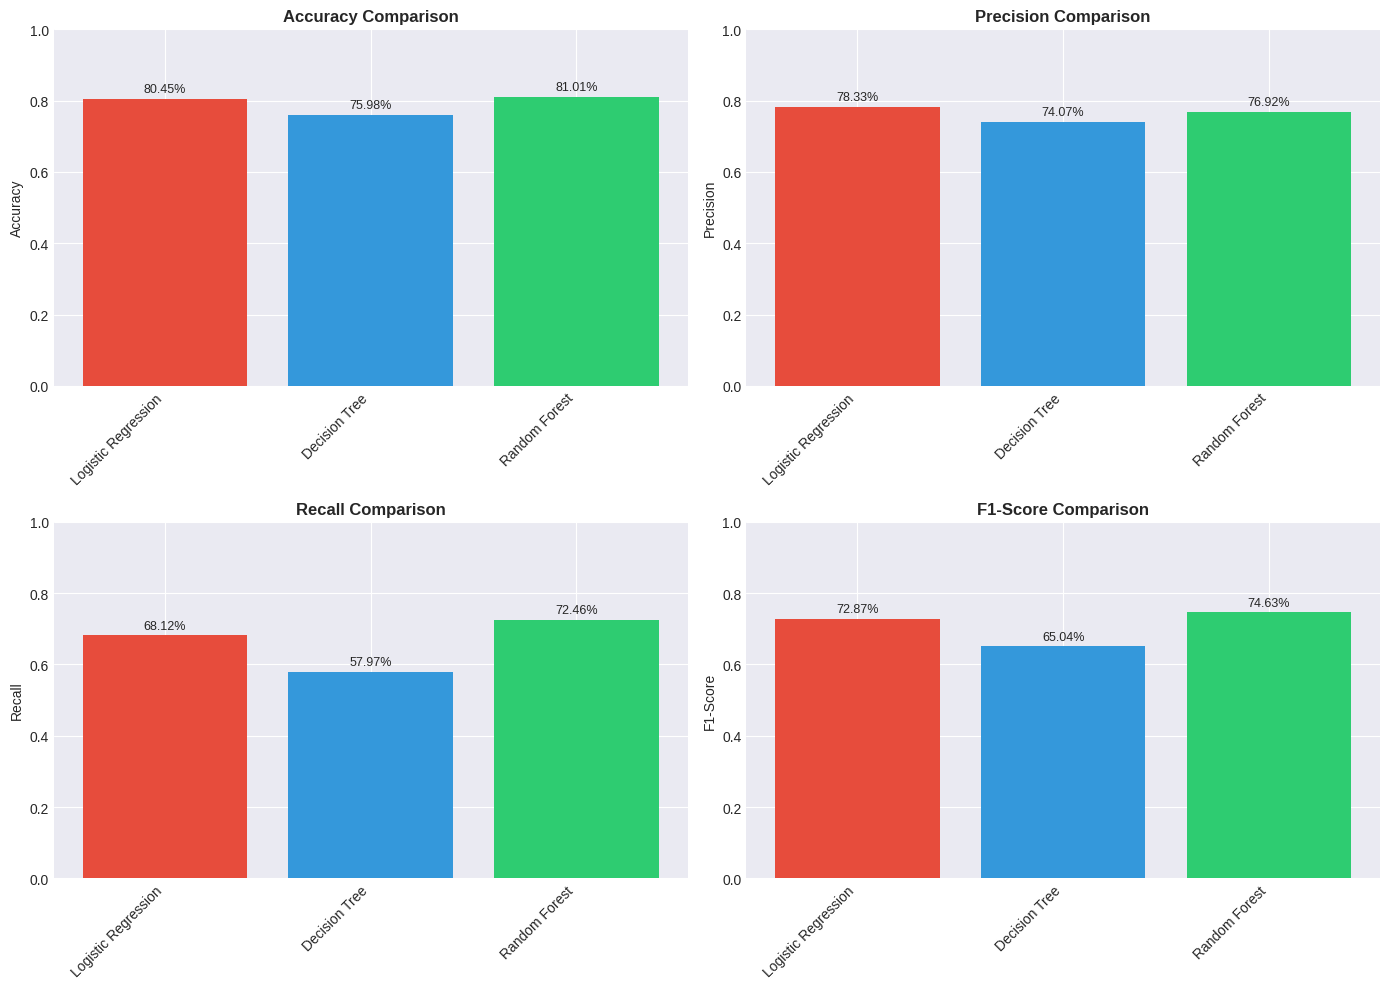

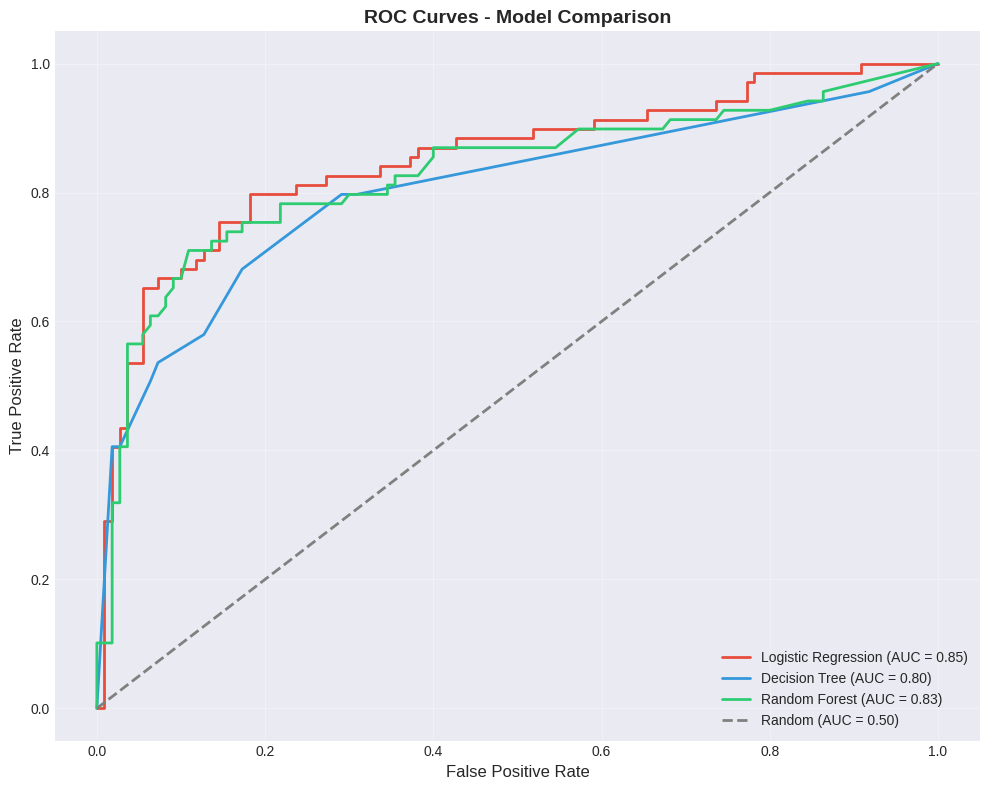

In [9]:
# Train and evaluate multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results_list = []

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred_model = model.predict(X_test)
    y_probs_model = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    results_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_model),
        'Precision': precision_score(y_test, y_pred_model),
        'Recall': recall_score(y_test, y_pred_model),
        'F1-Score': f1_score(y_test, y_pred_model),
        'AUC': roc_auc_score(y_test, y_probs_model)
    })

# Create results dataframe
comparison_df = pd.DataFrame(results_list)
print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.round(3))

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bar plot for each metric
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric],
                  color=['#e74c3c', '#3498db', '#2ecc71'])
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')

    # Add value labels
    for bar, score in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.2%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ROC curves for all models
plt.figure(figsize=(10, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71']

for (name, model), color in zip(models.items(), colors):
    y_probs_model = model.predict_proba(X_test)[:, 1]
    fpr_model, tpr_model, _ = roc_curve(y_test, y_probs_model)
    auc_model = roc_auc_score(y_test, y_probs_model)
    plt.plot(fpr_model, tpr_model, linewidth=2, color=color,
             label=f'{name} (AUC = {auc_model:.2f})')

plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=2, label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Create a comprehensive summary
print("="*70)
print("SUMMARY AND KEY TAKEAWAYS")
print("="*70)

print("""
 1. WHY ACCURACY ALONE IS MISLEADING:
   - On imbalanced datasets, high accuracy can be achieved by always predicting
     the majority class
   - The Titanic dataset has ~62% non-survivors, so a dummy classifier achieves
     62% accuracy while being completely useless

 2. IMPORTANCE OF CONFUSION MATRIX:
   - Shows the complete picture of model performance
   - Reveals the types of errors the model makes
   - Essential for understanding model strengths and weaknesses

 3. PRECISION VS RECALL TRADE-OFF:
   - Precision: Of all predicted survivors, how many actually survived?
   - Recall: Of all actual survivors, how many did we correctly identify?
   - In medical diagnosis, high recall is crucial (don't miss sick patients)
   - In spam detection, high precision is important (don't flag legitimate emails)

 4. F1-SCORE BALANCES BOTH:
   - Harmonic mean of precision and recall
   - Better metric for imbalanced datasets
   - Ranges from 0 (worst) to 1 (best)

 5. ROC CURVE AND AUC:
   - Shows model performance across all thresholds
   - AUC of 1.0 = perfect classifier
   - AUC of 0.5 = random guessing
   - Useful for comparing different models

 6. CROSS-VALIDATION:
   - Provides more reliable performance estimates
   - Reduces the impact of lucky/unlucky train-test splits
   - Essential for model selection and hyperparameter tuning
""")

# Final metrics summary
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
print(f"\n Best performing model: {best_model_name}")
print(f"   Based on F1-Score: {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'F1-Score']:.3f}")
print(f"   Based on AUC: {comparison_df.loc[comparison_df['AUC'].idxmax(), 'Model']} "
      f"({comparison_df.loc[comparison_df['AUC'].idxmax(), 'AUC']:.3f})")



SUMMARY AND KEY TAKEAWAYS

 1. WHY ACCURACY ALONE IS MISLEADING:
   - On imbalanced datasets, high accuracy can be achieved by always predicting 
     the majority class
   - The Titanic dataset has ~62% non-survivors, so a dummy classifier achieves 
     62% accuracy while being completely useless

 2. IMPORTANCE OF CONFUSION MATRIX:
   - Shows the complete picture of model performance
   - Reveals the types of errors the model makes
   - Essential for understanding model strengths and weaknesses

 3. PRECISION VS RECALL TRADE-OFF:
   - Precision: Of all predicted survivors, how many actually survived?
   - Recall: Of all actual survivors, how many did we correctly identify?
   - In medical diagnosis, high recall is crucial (don't miss sick patients)
   - In spam detection, high precision is important (don't flag legitimate emails)

 4. F1-SCORE BALANCES BOTH:
   - Harmonic mean of precision and recall
   - Better metric for imbalanced datasets
   - Ranges from 0 (worst) to 1 (best)

